# ICON custom run – swap radiation scheme

Run the GCM with ICON physics. Set `USE_RRTMGP = True` or `False` to switch between RRTMGP and ICON two-stream radiation.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax
jax.config.update('jax_disable_jit', False) # Turn off JIT because of an issue in shortwave_radiation.py:169
jax.config.update("jax_debug_infs", True) # doesn't add any time since the saved time is otherwise spent getting the nodal quantities
jax.config.update("jax_debug_nans", False) # some physics fields might be nan

In [3]:
from jcm.model import Model
from jcm.physics.icon.icon_physics import IconPhysics
from jcm.physics.icon.parameters import Parameters
from jcm.geometry import Geometry
from jcm.utils import get_coords
from jcm.physics.icon.radiation.radiation_scheme import radiation_scheme as radiation_scheme_icon
from jcm.physics.icon.radiation.radiation_scheme_rrtmgp import radiation_scheme_rrtmgp

# For now create a model with non-hybrid vertical coords, the Hybrid vertical coord support is still being worked on
coords = get_coords(hybrid_vertical=False, layers=40, spectral_truncation=31)
geometry = Geometry.from_coords(coords)

# Swap physics scheme: {rrtmgp: radiation_scheme_rrtmg, default: radiation_scheme_icon}
physics = IconPhysics(
    radiation_scheme_fn=radiation_scheme_rrtmgp
)
model = Model(
    geometry=geometry,
    use_hybrid_coords=False,
    physics=physics
)

save_interval, total_time = 1, 3
predictions = model.run(
    save_interval=save_interval,
    total_time=total_time,
)

In [4]:
# create non-hybrid coords
# from dinosaur.coordinate_systems import CoordinateSystem
# _coords = CoordinateSystem(model.coords.horizontal, model.coords.vertical.to_approx_sigma_coords(40))
pred_ds = predictions.to_xarray(physics)
pred_ds

Skipping single time dimension array: date.tyear with shape (1, 3)
Skipping single time dimension array: date.dt._delta._days with shape (1, 3)
Skipping single time dimension array: date.dt._delta._seconds with shape (1, 3)
Skipping single time dimension array: date.model_year with shape (1, 3)
Skipping single time dimension array: date.model_step with shape (1, 3)
Skipping single time dimension array: date.dt_seconds with shape (1, 3)
Skipping interface-level data: diagnostics.pressure_half with shape (3, 41, 96, 48)
Skipping interface-level data: diagnostics.height_half with shape (3, 41, 96, 48)
Skipping [time, ncols, channels] array: radiation.surface_albedo_vis with shape (3, 4608, 1)
Skipping [time, ncols, channels] array: radiation.surface_albedo_nir with shape (3, 4608, 1)
Skipping [time, ncols, channels] array: radiation.surface_emissivity with shape (3, 4608, 1)
Skipping interface-level multi-channel array: radiation.sw_flux_up with shape (3, 41, 96, 48, 1)
Skipping interface

<xarray.Dataset> Size: 77MB
Dimensions:                                  (time: 3, level: 40, lon: 96,
                                              lat: 48)
Coordinates:
  * lon                                      (lon) float64 768B 0.0 ... 356.2
  * lat                                      (lat) float64 384B -87.16 ... 87.16
  * level                                    (level) float32 160B 0.9875 ... ...
  * time                                     (time) datetime64[ns] 24B 2000-0...
Data variables: (12/67)
    vertical_diffusion.km                    (time, level, lon, lat) float32 2MB ...
    specific_humidity                        (time, level, lon, lat) float32 2MB ...
    chemistry.methane_loss                   (time, level, lon, lat) float32 2MB ...
    chemistry.ozone_production               (time, level, lon, lat) float32 2MB ...
    radiation.cos_zenith                     (time, lon, lat) float32 55kB ...
    aerosol.aod_total                        (time, lon, lat) float32 55kB ...
    ...                                       ...
    surface.roughness_length                 (time, lon, lat) float32 55kB ...
    diagnostics.air_density                  (time, level, lon, lat) float32 2MB ...
    convection.precip_conv                   (time, lon, lat) float32 55kB ...
    surface.cm                               (time, lon, lat) float32 55kB ...
    temperature                              (time, level, lon, lat) float32 2MB ...
    u_wind                                   (time, level, lon, lat) float32 2MB ...

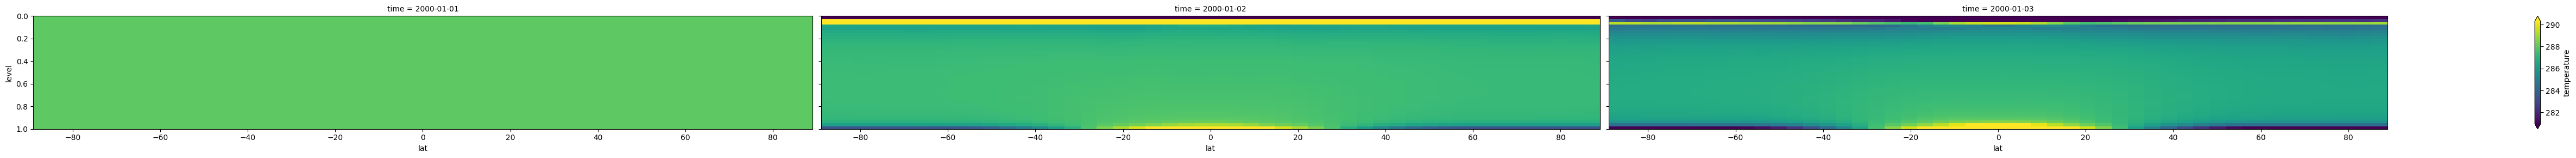

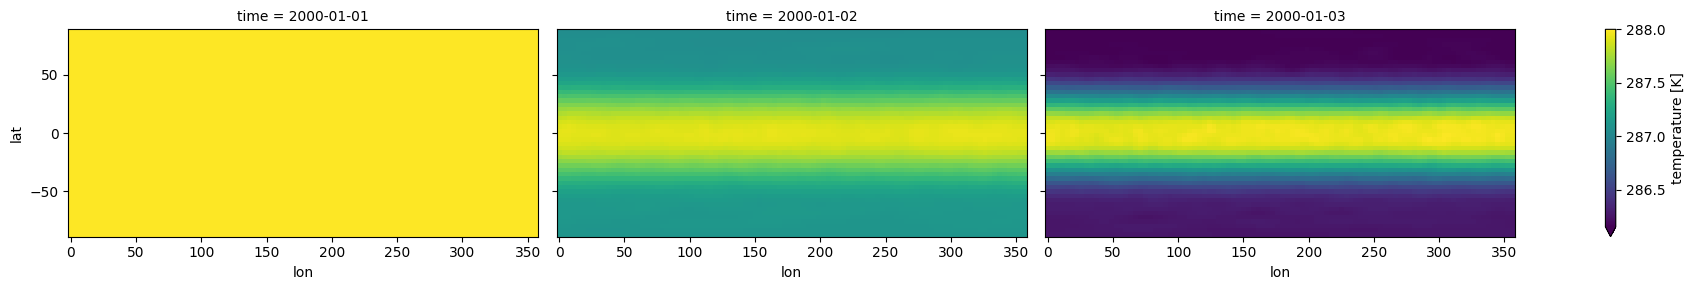

In [7]:
pred_ds['temperature'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False, robust=True)
pred_ds['temperature'].isel(level=3).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2, robust=True)